In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
from copy import deepcopy
warnings.filterwarnings("ignore")

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, mutual_info_classif

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

print("Library berhasil diimpor.")


In [ ]:
from google.colab import files

uploaded = files.upload()
nama_file = list(uploaded.keys())[0]

df = pd.read_csv(nama_file)

print("Dataset berhasil dimuat")
print("Jumlah baris dan kolom:", df.shape)

display(df.head())

Saving dataset_ai_proyek_2.1.csv to dataset_ai_proyek_2.1.csv
Dataset berhasil dimuat
Jumlah baris dan kolom: (1808, 8)


,Tahun,Bulan Rilis,Provinsi,Kode_Provinsi,Indeks_Ketersediaan,Indeks_Keterjangkauan,Indeks_Pemanfaatan,Indeks_Komposit
0,2022,Juli,Aceh,11,2,3,3,3
1,2022,Juli,Sumatera Utara,12,2,3,3,3
2,2022,Juli,Sumatera Barat,13,2,3,3,3
3,2022,Juli,Riau,14,2,3,3,3
4,2022,Juli,Jambi,15,2,3,3,3


In [ ]:
print("Informasi dataset:")
df.info()

print("\nMissing value:")
display(df.isnull().sum().to_frame("Jumlah Missing"))

print("\nJumlah data duplikat:", df.duplicated().sum())

print("\nStatistik numerik:")
display(df.describe().round(2))

Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1808 entries, 0 to 1807
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Tahun                  1808 non-null   int64 
 1   Bulan Rilis            1808 non-null   object
 2   Provinsi               1808 non-null   object
 3   Kode_Provinsi          1808 non-null   object
 4   Indeks_Ketersediaan    1808 non-null   int64 
 5   Indeks_Keterjangkauan  1808 non-null   int64 
 6   Indeks_Pemanfaatan     1808 non-null   int64 
 7   Indeks_Komposit        1808 non-null   int64 
dtypes: int64(5), object(3)
memory usage: 113.1+ KB

Missing value:


,Jumlah Missing
Tahun,0
Bulan Rilis,0
Provinsi,0
Kode_Provinsi,0
Indeks_Ketersediaan,0
Indeks_Keterjangkauan,0
Indeks_Pemanfaatan,0
Indeks_Komposit,0



Jumlah data duplikat: 0

Statistik numerik:


,Tahun,Indeks_Ketersediaan,Indeks_Keterjangkauan,Indeks_Pemanfaatan,Indeks_Komposit
count,1808.00,1808.00,1808.00,1808.00,1808.00
mean,2024.14,2.26,2.69,2.48,2.48
std,1.26,0.56,0.51,0.72,0.57
min,2022.00,1.00,1.00,1.00,1.00
25%,2023.00,2.00,2.00,2.00,2.00
50%,2024.00,2.00,3.00,3.00,3.00
75%,2025.00,3.00,3.00,3.00,3.00
max,2026.00,3.00,3.00,3.00,3.00


## TAHAP 1–3 — Data Preparation & Preprocessing

In [ ]:
peta_bulan = {
    "Januari": 1,
    "Februari": 2,
    "Maret": 3,
    "April": 4,
    "Mei": 5,
    "Juni": 6,
    "Juli": 7,
    "Agustus": 8,
    "September": 9,
    "Oktober": 10,
    "November": 11,
    "Desember": 12
}

df["Bulan_Num"] = df["Bulan Rilis"].map(peta_bulan)

print("Bulan yang gagal dipetakan:",
      df["Bulan_Num"].isnull().sum())

df["Periode"] = pd.to_datetime(
    dict(
        year=df["Tahun"],
        month=df["Bulan_Num"],
        day=1
    )
)

df = df.sort_values(
    ["Provinsi", "Periode"]
).reset_index(drop=True)

print(
    "Rentang data:",
    df["Periode"].min().strftime("%Y-%m"),
    "sampai",
    df["Periode"].max().strftime("%Y-%m")
)

print(
    "Duplikat Provinsi-Periode:",
    df.duplicated(["Provinsi", "Periode"]).sum()
)

Bulan yang gagal dipetakan: 0
Rentang data: 2022-07 sampai 2026-08
Duplikat Provinsi-Periode: 0


## TAHAP 4 — Menentukan Target Prediksi Bulan Berikutnya

In [ ]:
pilar = [
    "Indeks_Ketersediaan",
    "Indeks_Keterjangkauan",
    "Indeks_Pemanfaatan"
]

komposit = "Indeks_Komposit"

g = df.groupby("Provinsi", group_keys=False)

# Target = indeks komposit bulan berikutnya
df["Periode_Berikut"] = g["Periode"].shift(-1)

df["Target_Bulan_Berikutnya"] = g[komposit].shift(-1)

# Memastikan benar-benar bulan berikutnya
cek_bulan = (
    df["Periode_Berikut"]
    == df["Periode"] + pd.DateOffset(months=1)
)

jumlah_tidak_berurutan = (
    (~cek_bulan) &
    df["Periode_Berikut"].notna()
).sum()

print(
    "Transisi bulan yang tidak berurutan:",
    jumlah_tidak_berurutan
)

# Jika ada bulan yang lompat, target tidak digunakan
df.loc[
    ~cek_bulan,
    "Target_Bulan_Berikutnya"
] = np.nan

print(
    "Data tanpa target:",
    df["Target_Bulan_Berikutnya"].isna().sum()
)

Transisi bulan yang tidak berurutan: 0
Data tanpa target: 38


## TAHAP 5 — Feature Engineering

In [ ]:
# ==============================
# FITUR DASAR
# ==============================

fitur_dasar = pilar + [komposit]

# ==============================
# PERUBAHAN DARI BULAN SEBELUMNYA
# ==============================

for kolom in fitur_dasar:

    nama_fitur = (
        "Perubahan_" +
        kolom.replace("Indeks_", "")
    )

    df[nama_fitur] = (
        df.groupby("Provinsi")[kolom]
        .diff()
        .fillna(0)
    )


# ==============================
# LAG 1 BULAN
# ==============================

for kolom in fitur_dasar:

    nama_fitur = (
        "Lag1_" +
        kolom.replace("Indeks_", "")
    )

    df[nama_fitur] = (
        df.groupby("Provinsi")[kolom]
        .shift(1)
    )


# ==============================
# LAG 2 BULAN
# ==============================

for kolom in fitur_dasar:

    nama_fitur = (
        "Lag2_" +
        kolom.replace("Indeks_", "")
    )

    df[nama_fitur] = (
        df.groupby("Provinsi")[kolom]
        .shift(2)
    )


# ==============================
# RATA-RATA 3 BULAN
# ==============================

for kolom in fitur_dasar:

    nama_fitur = (
        "Rata3_" +
        kolom.replace("Indeks_", "")
    )

    df[nama_fitur] = (
        df.groupby("Provinsi")[kolom]
        .transform(
            lambda x: x.rolling(
                3,
                min_periods=1
            ).mean()
        )
    )

print("Feature engineering selesai.")

display(
    df[
        [
            "Provinsi",
            "Periode",
            "Indeks_Komposit",
            "Perubahan_Komposit",
            "Lag1_Komposit",
            "Lag2_Komposit",
            "Rata3_Komposit",
            "Target_Bulan_Berikutnya"
        ]
    ].head(10)
)

Feature engineering selesai.


,Provinsi,Periode,Indeks_Komposit,Perubahan_Komposit,Lag1_Komposit,Lag2_Komposit,Rata3_Komposit,Target_Bulan_Berikutnya
0,Aceh,2022-07-01,3,0.0,NaN,NaN,3.000000,2.0
1,Aceh,2022-08-01,2,-1.0,3.0,NaN,2.500000,3.0
2,Aceh,2022-09-01,3,1.0,2.0,3.0,2.666667,3.0
3,Aceh,2022-10-01,3,0.0,3.0,2.0,2.666667,3.0
4,Aceh,2022-11-01,3,0.0,3.0,3.0,3.000000,3.0
5,Aceh,2022-12-01,3,0.0,3.0,3.0,3.000000,3.0
6,Aceh,2023-01-01,3,0.0,3.0,3.0,3.000000,2.0
7,Aceh,2023-02-01,2,-1.0,3.0,3.0,2.666667,3.0
8,Aceh,2023-03-01,3,1.0,2.0,3.0,2.666667,3.0
9,Aceh,2023-04-01,3,0.0,3.0,2.0,2.666667,2.0


## TAHAP 6 — Feature Selection dan Fitur Model

In [ ]:
fitur_numerik = [
    "Indeks_Ketersediaan",
    "Indeks_Keterjangkauan",
    "Indeks_Pemanfaatan",
    "Indeks_Komposit",

    "Perubahan_Ketersediaan",
    "Perubahan_Keterjangkauan",
    "Perubahan_Pemanfaatan",
    "Perubahan_Komposit",

    "Lag1_Ketersediaan",
    "Lag1_Keterjangkauan",
    "Lag1_Pemanfaatan",
    "Lag1_Komposit",

    "Lag2_Ketersediaan",
    "Lag2_Keterjangkauan",
    "Lag2_Pemanfaatan",
    "Lag2_Komposit",

    "Rata3_Ketersediaan",
    "Rata3_Keterjangkauan",
    "Rata3_Pemanfaatan",
    "Rata3_Komposit"
]

fitur_kategorikal = ["Provinsi"]
target = "Target_Bulan_Berikutnya"

df_model = df.dropna(
    subset=[target] + fitur_numerik
).copy()

df_model[target] = df_model[target].astype(int)

print("Jumlah data untuk pemodelan:", len(df_model))
print("\nDistribusi target:")
display(
    df_model[target]
    .value_counts()
    .sort_index()
    .to_frame("Jumlah")
)

print("\nJumlah fitur awal:")
print("Fitur numerik :", len(fitur_numerik))
print("Fitur kategori:", len(fitur_kategorikal))


Jumlah data untuk pemodelan: 1694

Distribusi target:


,count
Target_Bulan_Berikutnya,
1,63
2,787
3,844


## TAHAP 7 — Exploratory Data Analysis (EDA)

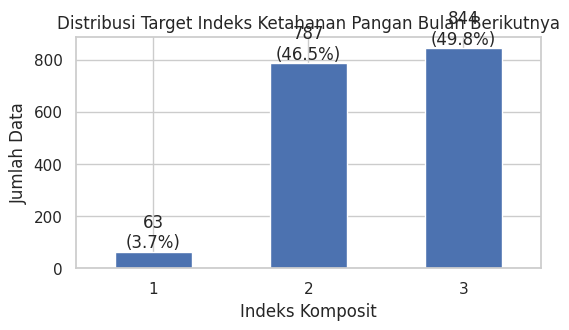

In [ ]:
# 1. Distribusi target
distribusi = df_model[target].value_counts().sort_index()

plt.figure(figsize=(6, 4))
ax = distribusi.plot(kind="bar", rot=0)
plt.title("Distribusi Target Indeks Komposit Bulan Berikutnya")
plt.xlabel("Kelas Target")
plt.ylabel("Jumlah Data")

for i, nilai in enumerate(distribusi.values):
    persentase = nilai / len(df_model) * 100
    ax.text(i, nilai, f"{nilai}\n({persentase:.1f}%)",
            ha="center", va="bottom")
plt.show()

# 2. Distribusi fitur utama
df_model[
    [
        "Indeks_Ketersediaan",
        "Indeks_Keterjangkauan",
        "Indeks_Pemanfaatan",
        "Indeks_Komposit"
    ]
].hist(figsize=(12, 8), bins=10)
plt.suptitle("Distribusi Fitur Utama", y=1.02)
plt.tight_layout()
plt.show()

# 3. Korelasi fitur numerik dengan target
korelasi = df_model[fitur_numerik + [target]].corr()[target]     .drop(target)     .sort_values(ascending=False)

plt.figure(figsize=(9, 6))
korelasi.head(10).sort_values().plot(kind="barh")
plt.title("10 Korelasi Fitur Teratas dengan Target")
plt.xlabel("Koefisien Korelasi")
plt.show()

display(korelasi.to_frame("Korelasi dengan Target").round(3))

# 4. Hubungan beberapa fitur utama dengan target
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, kolom in zip(
    axes,
    [
        "Indeks_Ketersediaan",
        "Indeks_Keterjangkauan",
        "Indeks_Pemanfaatan"
    ]
):
    sns.boxplot(data=df_model, x=target, y=kolom, ax=ax)
    ax.set_title(kolom.replace("_", " "))

plt.tight_layout()
plt.show()


## TAHAP 8 — Train-Test Split Berdasarkan Waktu

In [ ]:
# Pembagian berdasarkan waktu, bukan random split.
# 80% periode awal untuk training dan 20% periode akhir untuk testing.

periode_urut = np.sort(df_model["Periode"].unique())

batas_index = int(len(periode_urut) * 0.8)
batas_periode = periode_urut[batas_index]

train = df_model[df_model["Periode"] < batas_periode].copy()
test = df_model[df_model["Periode"] >= batas_periode].copy()

print("PEMBAGIAN DATA")
print("=" * 50)
print("Data training :", len(train), "baris")
print(
    "Periode training:",
    train["Periode"].min().strftime("%Y-%m"),
    "sampai",
    train["Periode"].max().strftime("%Y-%m")
)
print()
print("Data testing  :", len(test), "baris")
print(
    "Periode testing:",
    test["Periode"].min().strftime("%Y-%m"),
    "sampai",
    test["Periode"].max().strftime("%Y-%m")
)
print()
print(
    "Persentase training:",
    round(len(train) / len(df_model) * 100, 2), "%"
)
print(
    "Persentase testing:",
    round(len(test) / len(df_model) * 100, 2), "%"
)


PEMBAGIAN DATA
Data training : 1314 baris
Periode training: 2022-09 sampai 2025-09

Data testing  : 380 baris
Periode testing: 2025-10 sampai 2026-07

Persentase training: 77.57 %
Persentase testing: 22.43 %


## TAHAP 9 — Feature Selection (Data Training)

In [ ]:
X_train_raw = train[fitur_numerik + fitur_kategorikal]
y_train = train[target]

X_test_raw = test[fitur_numerik + fitur_kategorikal]
y_test = test[target]

# Preprocessing dilakukan terlebih dahulu.
preprocessor_fs = ColumnTransformer(
    transformers=[
        (
            "provinsi",
            OneHotEncoder(handle_unknown="ignore"),
            fitur_kategorikal
        ),
        (
            "numerik",
            "passthrough",
            fitur_numerik
        )
    ]
)

X_train_encoded = preprocessor_fs.fit_transform(X_train_raw)
X_test_encoded = preprocessor_fs.transform(X_test_raw)

# Total fitur setelah One Hot Encoding
nama_fitur_encoded = preprocessor_fs.get_feature_names_out()
jumlah_fitur_awal = len(nama_fitur_encoded)

# Mutual Information memilih fitur yang paling informatif terhadap target.
# Hanya training yang digunakan agar tidak terjadi data leakage.
K_FEATURES = min(40, jumlah_fitur_awal)

def mutual_info_fixed(X, y):
    return mutual_info_classif(
        X, y, random_state=42
    )

selector_report = SelectKBest(
    score_func=mutual_info_fixed,
    k=K_FEATURES
)

selector_report.fit(X_train_encoded, y_train)

selected_mask = selector_report.get_support()
fitur_terpilih = nama_fitur_encoded[selected_mask]
skor_mi = selector_report.scores_[selected_mask]

tabel_feature_selection = pd.DataFrame({
    "Fitur": fitur_terpilih,
    "Mutual Information": skor_mi
}).sort_values(
    "Mutual Information",
    ascending=False
).reset_index(drop=True)

print("FEATURE SELECTION")
print("=" * 50)
print("Fitur setelah One Hot Encoding :", jumlah_fitur_awal)
print("Fitur yang dipilih             :", K_FEATURES)
print("Fitur yang tidak dipilih       :", jumlah_fitur_awal - K_FEATURES)

print("\n20 fitur terpilih dengan skor tertinggi:")
display(tabel_feature_selection.head(20).round(4))


X_train: (1314, 21)
X_test : (380, 21)

Distribusi kelas training:


,Training
Target_Bulan_Berikutnya,
1,48
2,603
3,663



Distribusi kelas testing:


,Testing
Target_Bulan_Berikutnya,
1,15
2,184
3,181


## TAHAP 10 — Preprocessing + Feature Selection di Dalam Pipeline

In [ ]:
# Fungsi scoring dibuat agar Feature Selection selalu reproducible.
def mutual_info_fixed(X, y):
    return mutual_info_classif(
        X, y, random_state=42
    )

preprocessor = ColumnTransformer(
    transformers=[
        (
            "provinsi",
            OneHotEncoder(handle_unknown="ignore"),
            fitur_kategorikal
        ),
        (
            "numerik",
            "passthrough",
            fitur_numerik
        )
    ]
)

# Feature selection dilakukan setelah preprocessing dan hanya fit pada data training
# ketika pipeline dilatih.
feature_selector = SelectKBest(
    score_func=mutual_info_fixed,
    k=K_FEATURES
)

print(
    f"Pipeline siap: preprocessing -> feature selection ({K_FEATURES} fitur) -> model"
)


## TAHAP 11 — Algoritma 1: Decision Tree

In [ ]:
model_dt = Pipeline(
    steps=[
        ("preprocessor", deepcopy(preprocessor)),
        ("feature_selection", deepcopy(feature_selector)),
        (
            "model",
            DecisionTreeClassifier(
                max_depth=5,
                min_samples_leaf=5,
                random_state=42
            )
        )
    ]
)

model_dt.fit(X_train_raw, y_train)
pred_dt = model_dt.predict(X_test_raw)

print("Decision Tree selesai dilatih.")


Decision Tree selesai dilatih.


## TAHAP 11 — Algoritma 2: Random Forest

In [ ]:
model_rf = Pipeline(
    steps=[
        ("preprocessor", deepcopy(preprocessor)),
        ("feature_selection", deepcopy(feature_selector)),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=8,
                min_samples_leaf=3,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

model_rf.fit(X_train_raw, y_train)
pred_rf = model_rf.predict(X_test_raw)

print("Random Forest selesai dilatih.")


Random Forest selesai dilatih.


## TAHAP 11 — Algoritma 3: Random Forest Balanced

In [ ]:
model_rf_balanced = Pipeline(
    steps=[
        ("preprocessor", deepcopy(preprocessor)),
        ("feature_selection", deepcopy(feature_selector)),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=8,
                min_samples_leaf=3,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

model_rf_balanced.fit(X_train_raw, y_train)
pred_rf_balanced = model_rf_balanced.predict(X_test_raw)

print("Random Forest Balanced selesai dilatih.")


Random Forest Balanced selesai dilatih.


## Baseline — Pembanding Sederhana

In [ ]:
# Baseline: menggunakan nilai Indeks_Komposit saat ini
# sebagai prediksi untuk bulan berikutnya.
pred_baseline = X_test_raw["Indeks_Komposit"].astype(int)

print("Baseline dibuat.")


Baseline dibuat.


## TAHAP 12 — Evaluasi Model

In [ ]:
def evaluasi_model(nama, y_true, y_pred, y_proba=None, classes=None):
    hasil_eval = {
        "Model": nama,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision Macro": precision_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "Recall Macro": recall_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "F1 Macro": f1_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "Precision Kelas 1": precision_score(
            y_true, y_pred, labels=[1], average="macro", zero_division=0
        ),
        "Recall Kelas 1": recall_score(
            y_true, y_pred, labels=[1], average="macro", zero_division=0
        ),
        "ROC-AUC": np.nan
    }

    if y_proba is not None and classes is not None:
        hasil_eval["ROC-AUC"] = roc_auc_score(
            y_true,
            y_proba,
            multi_class="ovr",
            average="macro",
            labels=classes
        )

    return hasil_eval


proba_dt = model_dt.predict_proba(X_test_raw)
proba_rf = model_rf.predict_proba(X_test_raw)
proba_rfb = model_rf_balanced.predict_proba(X_test_raw)

hasil = pd.DataFrame([
    evaluasi_model("Baseline", y_test, pred_baseline),

    evaluasi_model(
        "Decision Tree",
        y_test,
        pred_dt,
        proba_dt,
        model_dt.named_steps["model"].classes_
    ),

    evaluasi_model(
        "Random Forest",
        y_test,
        pred_rf,
        proba_rf,
        model_rf.named_steps["model"].classes_
    ),

    evaluasi_model(
        "Random Forest Balanced",
        y_test,
        pred_rf_balanced,
        proba_rfb,
        model_rf_balanced.named_steps["model"].classes_
    )
])

display(hasil.round(3))


,Model,Accuracy,Precision Macro,Recall Macro,F1 Macro,Precision Kelas 1,Recall Kelas 1
0,Baseline,0.668,0.575,0.566,0.569,0.357,0.333
1,Decision Tree,0.674,0.602,0.528,0.547,0.429,0.200
2,Random Forest,0.700,0.636,0.506,0.515,0.500,0.067
3,Random Forest Balanced,0.629,0.529,0.641,0.541,0.196,0.667


## Perbandingan Performa Model

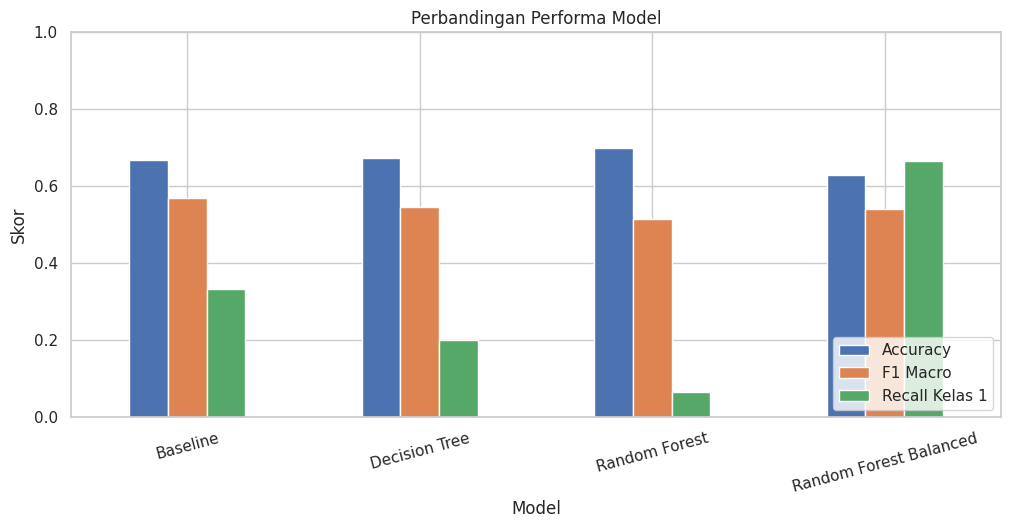

In [ ]:
hasil_plot = hasil.set_index("Model")

hasil_plot[
    ["Accuracy", "F1 Macro", "Recall Kelas 1", "ROC-AUC"]
].plot(
    kind="bar",
    figsize=(12, 5)
)

plt.title("Perbandingan Performa Model")
plt.ylabel("Skor")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.legend(loc="lower right")
plt.show()


## Classification Report

In [ ]:
for nama, prediksi in [
    ("Decision Tree", pred_dt),
    ("Random Forest", pred_rf),
    ("Random Forest Balanced", pred_rf_balanced)
]:
    print("=" * 65)
    print(nama)
    print("=" * 65)
    print(
        classification_report(
            y_test,
            prediksi,
            labels=[1, 2, 3],
            zero_division=0
        )
    )


Decision Tree
              precision    recall  f1-score   support

           1       0.43      0.20      0.27        15
           2       0.63      0.77      0.70       184
           3       0.74      0.61      0.67       181

    accuracy                           0.67       380
   macro avg       0.60      0.53      0.55       380
weighted avg       0.68      0.67      0.67       380

Random Forest
              precision    recall  f1-score   support

           1       0.50      0.07      0.12        15
           2       0.67      0.74      0.71       184
           3       0.74      0.71      0.72       181

    accuracy                           0.70       380
   macro avg       0.64      0.51      0.51       380
weighted avg       0.70      0.70      0.69       380

Random Forest Balanced
              precision    recall  f1-score   support

           1       0.20      0.67      0.30        15
           2       0.64      0.56      0.60       184
           3       0.75 

## Confusion Matrix

In [ ]:
model_predictions = {
    "Baseline": pred_baseline,
    "Decision Tree": pred_dt,
    "Random Forest": pred_rf,
    "Random Forest Balanced": pred_rf_balanced
}

for nama, prediksi in model_predictions.items():
    print("\n" + "=" * 55)
    print("Confusion Matrix:", nama)

    cm = confusion_matrix(
        y_test,
        prediksi,
        labels=[1, 2, 3]
    )

    display(
        pd.DataFrame(
            cm,
            index=["Aktual 1", "Aktual 2", "Aktual 3"],
            columns=["Prediksi 1", "Prediksi 2", "Prediksi 3"]
        )
    )



Confusion Matrix: Baseline


,Prediksi 1,Prediksi 2,Prediksi 3
Aktual 1,5,10,0
Aktual 2,9,128,47
Aktual 3,0,60,121



Confusion Matrix: Decision Tree


,Prediksi 1,Prediksi 2,Prediksi 3
Aktual 1,3,12,0
Aktual 2,4,142,38
Aktual 3,0,70,111



Confusion Matrix: Random Forest


,Prediksi 1,Prediksi 2,Prediksi 3
Aktual 1,1,14,0
Aktual 2,1,137,46
Aktual 3,0,53,128



Confusion Matrix: Random Forest Balanced


,Prediksi 1,Prediksi 2,Prediksi 3
Aktual 1,10,5,0
Aktual 2,39,103,42
Aktual 3,2,53,126


## TAHAP 13 — Pemilihan Model

In [ ]:
hasil_model = hasil[
    hasil["Model"].isin([
        "Decision Tree",
        "Random Forest",
        "Random Forest Balanced"
    ])
].copy()

# Model terbaik secara keseluruhan: F1 Macro tertinggi.
nama_terbaik = (
    hasil_model
    .sort_values("F1 Macro", ascending=False)
    .iloc[0]["Model"]
)

# Model yang diprioritaskan untuk mendeteksi kelas rentan:
# Recall kelas 1 tertinggi.
nama_model_risiko = (
    hasil_model
    .sort_values(
        ["Recall Kelas 1", "F1 Macro"],
        ascending=[False, False]
    )
    .iloc[0]["Model"]
)

model_dict = {
    "Decision Tree": model_dt,
    "Random Forest": model_rf,
    "Random Forest Balanced": model_rf_balanced
}

model_terbaik = model_dict[nama_terbaik]
model_operasional = model_dict[nama_model_risiko]

print("MODEL TERBAIK BERDASARKAN F1 MACRO :", nama_terbaik)
print("MODEL PRIORITAS UNTUK DETEKSI RENTAN:", nama_model_risiko)

display(
    hasil_model[
        [
            "Model",
            "Accuracy",
            "F1 Macro",
            "Recall Kelas 1",
            "ROC-AUC"
        ]
    ].round(3)
)

print(
    "\nCatatan: model terbaik dan model prioritas risiko "
    "bisa berbeda karena tujuan evaluasinya berbeda."
)


MODEL TERBAIK: Decision Tree


,Model,Accuracy,Precision Macro,Recall Macro,F1 Macro,Precision Kelas 1,Recall Kelas 1
1,Decision Tree,0.674,0.602,0.528,0.547,0.429,0.2


## TAHAP 14 — Feature Importance Model Operasional

10 fitur paling berpengaruh:


,Feature Importance
Rata3_Pemanfaatan,0.139580
Indeks_Pemanfaatan,0.124782
Lag1_Pemanfaatan,0.098624
Rata3_Komposit,0.076378
Lag2_Pemanfaatan,0.075724
Indeks_Komposit,0.051533
Rata3_Keterjangkauan,0.046552
Lag2_Komposit,0.040861
Lag1_Komposit,0.037240
Lag1_Keterjangkauan,0.035725


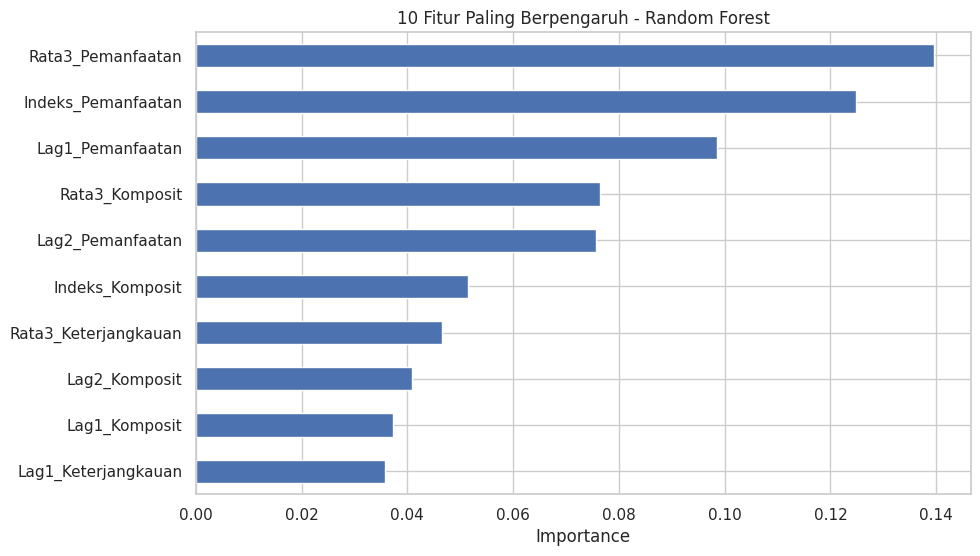

In [ ]:
# Feature importance harus berasal dari model yang digunakan
# untuk prediksi operasional, bukan model lain.
preprocessor_fitted = model_operasional.named_steps["preprocessor"]
selector_fitted = model_operasional.named_steps["feature_selection"]
model_fitted = model_operasional.named_steps["model"]

nama_fitur_awal = preprocessor_fitted.get_feature_names_out()
mask_terpilih = selector_fitted.get_support()
nama_fitur_terpilih = nama_fitur_awal[mask_terpilih]

importance = pd.Series(
    model_fitted.feature_importances_,
    index=nama_fitur_terpilih
).sort_values(ascending=False)

print("Jumlah fitur setelah preprocessing :", len(nama_fitur_awal))
print("Jumlah fitur yang dipilih         :", len(nama_fitur_terpilih))

print("\n10 fitur paling berpengaruh pada model operasional:")
display(
    importance.head(10).to_frame("Feature Importance").round(4)
)

plt.figure(figsize=(10, 6))
importance.head(10).sort_values().plot(kind="barh")
plt.title(
    f"10 Fitur Paling Berpengaruh - {nama_model_risiko}"
)
plt.xlabel("Importance")
plt.show()


## TAHAP 15 — Prediksi Bulan Berikutnya

In [ ]:
periode_terakhir = df["Periode"].max()

data_terbaru = df[
    df["Periode"] == periode_terakhir
].copy()

X_prediksi = data_terbaru[
    fitur_numerik + fitur_kategorikal
]

# Prediksi operasional menggunakan model dengan recall kelas 1 terbaik.
prediksi = model_operasional.predict(X_prediksi)

probabilitas = model_operasional.predict_proba(X_prediksi)

kelas_model = model_operasional.named_steps["model"].classes_

data_terbaru[
    "Prediksi_Indeks_Bulan_Depan"
] = prediksi

if 1 in kelas_model:
    posisi_kelas_1 = list(kelas_model).index(1)
    data_terbaru["Peluang_Rentan_Persen"] = (
        probabilitas[:, posisi_kelas_1] * 100
    ).round(2)
else:
    data_terbaru["Peluang_Rentan_Persen"] = 0.0

periode_prediksi = (
    periode_terakhir + pd.DateOffset(months=1)
)

print(
    "Data terakhir:",
    periode_terakhir.strftime("%B %Y")
)
print(
    "Periode yang diprediksi:",
    periode_prediksi.strftime("%B %Y")
)
print(
    "Model yang digunakan untuk prediksi:",
    nama_model_risiko
)


Data terakhir: August 2026
Periode yang diprediksi: September 2026


## Hasil Prediksi

In [ ]:
hasil_prediksi = data_terbaru[
    [
        "Provinsi",
        "Indeks_Komposit",
        "Prediksi_Indeks_Bulan_Depan",
        "Peluang_Rentan_Persen"
    ]
].copy()

hasil_prediksi = hasil_prediksi.sort_values(
    "Peluang_Rentan_Persen",
    ascending=False
).reset_index(drop=True)

hasil_prediksi.index = hasil_prediksi.index + 1

print("HASIL PREDIKSI KETAHANAN PANGAN")
print("Periode:", periode_prediksi.strftime("%B %Y"))
display(hasil_prediksi)


HASIL PREDIKSI KETAHANAN PANGAN
Periode: September 2026


,Provinsi,Indeks_Komposit,Prediksi_Indeks_Bulan_Depan,Peluang_Rentan_Persen
1,Papua Barat,2,2,37.50
2,Papua Selatan,2,2,17.02
3,Papua Barat Daya,1,2,17.02
4,Papua,2,2,17.02
5,Sulawesi Barat,1,2,17.02
6,Nusa Tenggara Timur,2,2,8.33
7,Kalimantan Barat,2,2,7.35
8,Sulawesi Tengah,3,2,2.58
9,Papua Pegunungan,2,2,2.58
10,Kalimantan Timur,2,2,2.58


In [ ]:
print("JUMLAH DATA PREDIKSI:", len(hasil_prediksi))

print("\nDistribusi hasil prediksi:")
display(
    hasil_prediksi[
        "Prediksi_Indeks_Bulan_Depan"
    ].value_counts()
    .sort_index()
    .to_frame("Jumlah")
)


JUMLAH DATA PREDIKSI: 38


,Provinsi,Indeks_Komposit,Prediksi_Indeks_Bulan_Depan,Peluang_Rentan_Persen
1,Papua Barat,2,2,37.50
2,Papua Selatan,2,2,17.02
3,Papua Barat Daya,1,2,17.02
4,Papua,2,2,17.02
5,Sulawesi Barat,1,2,17.02
6,Nusa Tenggara Timur,2,2,8.33
7,Kalimantan Barat,2,2,7.35
8,Sulawesi Tengah,3,2,2.58
9,Papua Pegunungan,2,2,2.58
10,Kalimantan Timur,2,2,2.58



Distribusi hasil prediksi:
Prediksi_Indeks_Bulan_Depan
3    24
2    14
Name: count, dtype: int64


## TAHAP 16 — Provinsi Prioritas / Rentan

In [ ]:
jumlah_prioritas = 10

provinsi_prioritas = (
    hasil_prediksi[
        hasil_prediksi["Prediksi_Indeks_Bulan_Depan"] == 1
    ]
    .sort_values(
        "Peluang_Rentan_Persen",
        ascending=False
    )
    .head(jumlah_prioritas)
)

print("PROVINSI YANG DIPREDIKSI RENTAN")
print("Periode:", periode_prediksi.strftime("%B %Y"))

if len(provinsi_prioritas) == 0:
    print(
        "Model tidak memprediksi kelas 1 pada periode tersebut. "
        "Ini tidak berarti kondisi rentan pasti tidak ada."
    )
else:
    display(provinsi_prioritas)


PROVINSI YANG DIPREDIKSI RENTAN
Periode: September 2026


,Provinsi,Indeks_Komposit,Prediksi_Indeks_Bulan_Depan,Peluang_Rentan_Persen


## TAHAP 17 — Kesimpulan dan Rekomendasi

In [ ]:
baris_f1 = hasil[
    hasil["Model"] == nama_terbaik
].iloc[0]

baris_risiko = hasil[
    hasil["Model"] == nama_model_risiko
].iloc[0]

print("=" * 75)
print("KESIMPULAN DAN REKOMENDASI")
print("=" * 75)

print(
    f"Periode data terakhir       : {periode_terakhir.strftime('%B %Y')}"
)
print(
    f"Periode yang diprediksi     : {periode_prediksi.strftime('%B %Y')}"
)
print(
    f"Data training               : {len(train)} baris"
)
print(
    f"Data testing                : {len(test)} baris"
)
print(
    f"Model terbaik berdasarkan F1 Macro : {nama_terbaik}"
)
print(
    f"Accuracy model terbaik      : {baris_f1['Accuracy']:.3f}"
)
print(
    f"F1 Macro model terbaik      : {baris_f1['F1 Macro']:.3f}"
)
print(
    f"Model prioritas deteksi rentan : {nama_model_risiko}"
)
print(
    f"Recall kelas 1 model risiko : {baris_risiko['Recall Kelas 1']:.3f}"
)
print(
    f"Jumlah provinsi diprediksi  : {len(hasil_prediksi)}"
)
print(
    f"Jumlah provinsi kelas 1     : {len(provinsi_prioritas)}"
)

print("\nREKOMENDASI:")
print(
    "1. Gunakan model terbaik berdasarkan F1 Macro untuk melihat "
    "performa keseluruhan."
)
print(
    "2. Untuk tujuan deteksi kondisi rentan, pertimbangkan model "
    "dengan Recall kelas 1 tertinggi."
)
print(
    "3. Provinsi yang diprediksi kelas 1 menjadi prioritas "
    "pemantauan lebih lanjut."
)
print(
    "4. Hasil prediksi AI digunakan sebagai alat bantu pengambilan "
    "keputusan, bukan sebagai keputusan akhir."
)

if len(provinsi_prioritas) > 0:
    print("\nPROVINSI PRIORITAS:")
    for i, row in provinsi_prioritas.reset_index(drop=True).iterrows():
        print(
            f"{i+1}. {row['Provinsi']} "
            f"({row['Peluang_Rentan_Persen']:.2f}% peluang kelas 1)"
        )
else:
    print(
        "\nTidak ada provinsi yang diprediksi kelas 1 pada periode "
        "prediksi menggunakan model operasional."
    )


RINGKASAN HASIL PREDIKSI KETAHANAN PANGAN
Periode data terakhir      : August 2026
Periode yang diprediksi    : September 2026
Data training              : 1314 baris
Data testing               : 380 baris
Model terbaik              : Decision Tree
Accuracy                   : 0.674
F1 Macro                   : 0.547
Recall kelas 1             : 0.200
Jumlah provinsi diprediksi : 38
Jumlah provinsi diprediksi rentan (kelas 1)          : 0

Provinsi prioritas:


### Catatan

In [ ]:
print(
    "Notebook telah dirapikan: evaluasi, feature selection, ROC-AUC, "
    "pemilihan model, prediksi, dan rekomendasi berada dalam satu alur."
)


RINGKASAN HASIL PREDIKSI KETAHANAN PANGAN
Periode data terakhir      : August 2026
Periode yang diprediksi    : September 2026
Data training              : 1314 baris
Data testing               : 380 baris
Model terbaik              : Decision Tree
Accuracy                   : 0.674
F1 Macro                   : 0.547
Recall kelas 1             : 0.200
Jumlah provinsi diprediksi : 38
Jumlah provinsi diprediksi rentan (kelas 1)          : 0

Provinsi prioritas:
